# Evaluación de Resultados
En el siguiente cuaderno, se muestran técnicas para la evaluación de los resultados de una predicción con un algoritmo de Machine Learning. Al igual que en cuadernos anteriores, se trabajará con el dataset **NSL-KDD**, una versión mejorada de KDD’99 diseñada para evaluar sistemas de detección de intrusos (IDS) en tráfico de red.  

De forma general, NSL-KDD contiene registros de conexiones etiquetadas como **tráfico normal** o **tipos de ataque**, por lo que es útil como conjunto de referencia para tareas de clasificación, análisis exploratorio y comparación de modelos.

Aunque no representa por completo las redes reales actuales, NSL-KDD sigue siendo ampliamente utilizado en investigación por su estructura, tamaño manejable y etiquetas estandarizadas.

### Fuente del dataset
El siguiente dataset puede descargarse en este enlace: **https://www.kaggle.com/datasets/hassan06/nslkdd**. 

## Import de librerías

In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, f1_score, recall_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

## Funciones auxiliares

In [90]:
# Función para dividir el dataset en conjuntos de entrenamiento, validación y prueba
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

In [91]:
# Construcción de un pipeline para los atributos numéricos
num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('rbst_scaler', RobustScaler()),
    ])

In [92]:
# Transormador para codificar únicamente las columnas categoricas y devolver un df
class CustomOneHotEncoder(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        self._oh = OneHotEncoder()
        self._columns = None
        
    def fit(self, X, y=None):
        X_cat = X.select_dtypes(include=['object'])
        self._columns = pd.get_dummies(X_cat).columns
        self._oh.fit(X_cat)
        return self
        
    def transform(self, X, y=None):
        X_copy = X.copy()
        X_cat = X_copy.select_dtypes(include=['object'])
        X_num = X_copy.select_dtypes(exclude=['object'])
        X_cat_oh = self._oh.transform(X_cat)
        X_cat_oh = pd.DataFrame(X_cat_oh.toarray(), 
                                columns=self._columns, 
                                index=X_copy.index)
        X_copy.drop(list(X_cat), axis=1, inplace=True)
        return X_copy.join(X_cat_oh)

In [93]:
# Transofrmador que prepara todo el conjunto de datos llamando pipelines y transformadores personalizados
class DataFramePreparer(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        self._full_pipeline = None
        self._columns = None
        
    def fit(self, X, y=None):
        num_attribs = list(X.select_dtypes(exclude=['object']))
        cat_attribs = list(X.select_dtypes(include=['object']))
        self._full_pipeline = ColumnTransformer([
                ("num", num_pipeline, num_attribs),
                ("cat", CustomOneHotEncoder(), cat_attribs),
        ])
        self._full_pipeline.fit(X)
        self._columns = pd.get_dummies(X).columns
        return self
        
    def transform(self, X, y=None):
        X_copy = X.copy()
        X_prep = self._full_pipeline.transform(X_copy)
        return pd.DataFrame(X_prep, 
                            columns=self._columns, 
                            index=X_copy.index)

### Lectura del conjunto de datos

In [94]:
df = pd.read_csv("data/KDDTrain+.csv")
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


In [95]:
# División del dataset en conjuntos de entrenamiento, validación y prueba
train_set, val_set, test_set = train_val_test_split(df)

In [96]:
train_set.shape[0], val_set.shape[0], test_set.shape[0]

(75583, 25195, 25195)

Se separan las etiquetas de las características de entradas

In [97]:
# Conjunto de datos general
X_df = df.drop("class", axis=1)
y_df = df["class"].copy()

In [98]:
# Conjunto de datos de entrenamiento
X_train = train_set.drop("class", axis=1)
y_train = np.where(train_set["class"] == "normal", "normal", "anomaly")

In [99]:
# Conjunto de datos de validación
X_val = val_set.drop("class", axis=1)
y_val = np.where(val_set["class"] == "normal", "normal", "anomaly")

In [100]:
# Conjunto de datos de pruebas
X_test = test_set.drop("class", axis=1)
y_test = np.where(test_set["class"] == "normal", "normal", "anomaly")

### Preparación del conjunto de datos

In [101]:
# Instancia del transformador para preparar los conjuntos de datos
data_preparer = DataFramePreparer()

In [102]:
# Fit del transformador con el conjunto de datos general para que aprenda las columnas a transformar
data_preparer.fit(X_df)

DataFramePreparer()

In [103]:
# Transformación del conjunto de datos de entrenamiento 
X_train_prep = data_preparer.transform(X_train)

In [104]:
X_train.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
98320,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,65,0.31,0.01,0.31,0.00,0.0,0.0,0.0,0.0,18
8590,0,tcp,smtp,SF,1762,331,0,0,0,0,...,122,0.73,0.07,0.03,0.02,0.0,0.0,0.0,0.0,21
91385,0,icmp,eco_i,SF,8,0,0,0,0,0,...,126,1.00,0.00,1.00,0.25,0.0,0.0,0.0,0.0,15
54349,0,tcp,csnet_ns,S0,0,0,0,0,0,0,...,18,0.07,0.07,0.00,0.00,1.0,1.0,0.0,0.0,19
69568,0,tcp,smtp,SF,1518,342,0,0,0,0,...,125,0.66,0.05,0.01,0.02,0.0,0.0,0.0,0.0,21
65413,0,tcp,http,SF,342,1148,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,21
106434,0,tcp,http,SF,247,11193,0,0,0,0,...,255,1.00,0.00,0.09,0.01,0.0,0.0,0.0,0.0,21
16874,0,tcp,http,SF,314,255,0,0,0,0,...,255,1.00,0.00,0.04,0.04,0.0,0.0,0.0,0.0,21
106132,0,udp,domain_u,SF,45,131,0,0,0,0,...,226,0.89,0.02,0.00,0.00,0.0,0.0,0.0,0.0,18
6183,0,tcp,uucp,S0,0,0,0,0,0,0,...,15,0.06,0.07,0.00,0.00,1.0,1.0,0.0,0.0,19


In [105]:
X_train_prep.head(10)

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
98320,0.0,3.579710,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8590,0.0,6.224638,0.641473,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
91385,0.0,-0.130435,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
54349,0.0,-0.159420,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
69568,0.0,5.340580,0.662791,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
65413,0.0,1.079710,2.224806,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
106434,0.0,0.735507,21.691860,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16874,0.0,0.978261,0.494186,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
106132,0.0,0.003623,0.253876,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6183,0.0,-0.159420,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [106]:
X_val_prep = data_preparer.transform(X_val)

## Entrenamiento de un algoritmo de Regresión Logística

In [ ]:
# Se entrena con 10 iteraciones para que el proceso sea más rápido, pero se puede aumentar a 1000 para obtener mejores resultados
clf = LogisticRegression(solver="newton-cg", max_iter=10)
clf.fit(X_train_prep, y_train)

/home/diego/miniconda3/lib/python3.13/site-packages/sklearn/utils/optimize.py:319: ConvergenceWarning: newton-cg failed to converge at loss = 0.2623816415959636. Increase the number of iterations.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Predicción de nuevos ejemplos

In [108]:
# Se realiza la predicción con el modelo entrenado sobre el conjunto de validación preparado
y_pred = clf.predict(X_val_prep)

## Matriz de confusión

In [109]:
confusion_matrix(y_val, y_pred, labels=["normal", "anomaly"])

array([[12398,   923],
       [  273, 11601]])

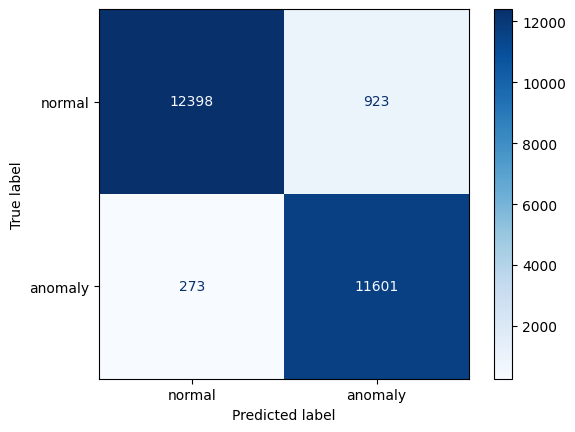

In [110]:
ConfusionMatrixDisplay.from_estimator(
    clf,
    X_val_prep,
    y_val,
    labels=["normal", "anomaly"],
    cmap="Blues",
    values_format="d"
 )

## Métricas derivadas


Para evaluar el modelo se va a usar precisión, recall y F1-score porque no basta con ver solo cuántos aciertos generales tiene.

- **Precisión (precision):** de todos los casos que el modelo marcó como anomalía, cuántos realmente eran anomalía. Sirve para medir qué tanto “se equivoca” dando falsas alarmas.

- **Recall (sensibilidad):** de todas las anomalías reales, cuántas logró detectar el modelo.  Sirve para saber si se están escapando ataques.

- **F1-score:** combina precisión y recall en una sola métrica (promedio armónico). Es útil cuando queremos un equilibrio entre detectar ataques y no generar demasiadas falsas alertas.

En este cuaderno, como se está clasificando tráfico en normal o anomalía, estas métricas sirven para entender mejor el desempeño real del detector de intrusos.

In [112]:
print("Precisión:", precision_score(y_val, y_pred, pos_label='anomaly'))
print("Recall:", recall_score(y_val, y_pred, pos_label='anomaly'))
print("F1 score:", f1_score(y_val, y_pred, pos_label='anomaly'))

Precisión: 0.9263015011178537
Recall: 0.9770085901970692
F1 score: 0.95097958849086


El modelo prioriza bien la detección de ataques (recall alto) sin perder demasiado en falsas alarmas (precisión también alta). En conclusión, está funcionando bien y está balanceado (F1 alto)

## Curvas ROC y PR

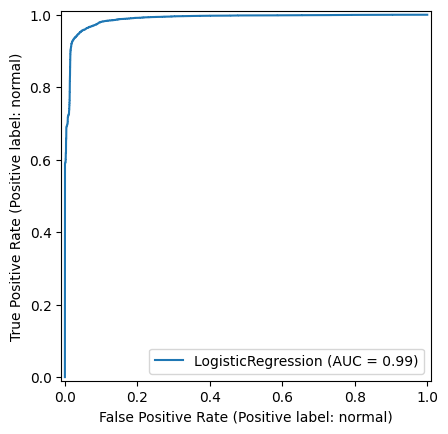

In [ ]:
# Evaluación del modelo con ROC para visualizar la capacidad del modelo 
# para distinguir entre clases, especialmente en casos de desequilibrio de clases
RocCurveDisplay.from_estimator(clf, X_val_prep, y_val)

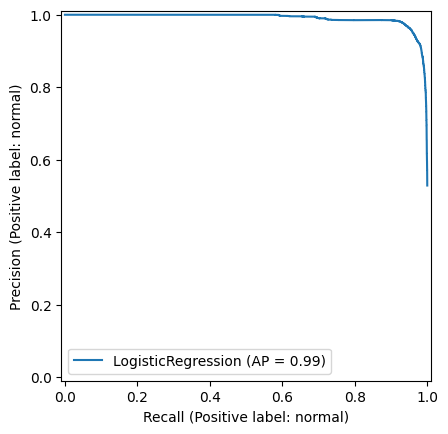

In [114]:
# Evaluación del modelo con Precision-Recall para visualizar la relación 
# entre precisión y recall, especialmente útil en casos de desequilibrio de clases
PrecisionRecallDisplay.from_estimator(clf, X_val_prep, y_val)

## Evaluación del modelo con el dataset de test

In [115]:
# Se transforman los datos de validación para realizar la evaluación final del modelo sobre el conjunto de pruebas
X_test_prep = data_preparer.transform(X_test)

In [116]:
y_pred = clf.predict(X_test_prep)

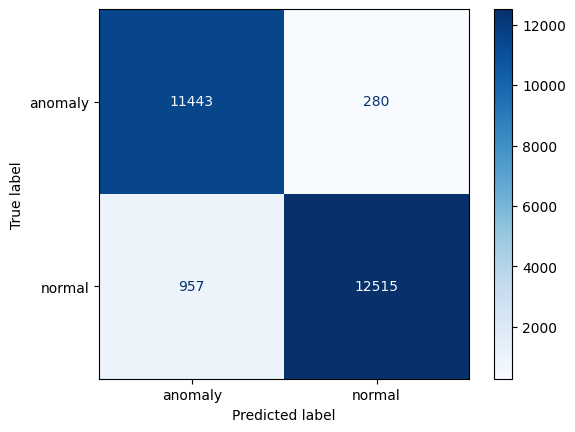

In [117]:
ConfusionMatrixDisplay.from_estimator(clf, X_test_prep, y_test, cmap="Blues", values_format='d')

In [118]:
print("F1 score:", f1_score(y_test, y_pred, pos_label='anomaly'))

F1 score: 0.9487211375036273
